In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Filtro RC

$$w_{c} = \frac{1}{RC}; \hspace{1cm}  w_{c}=2\pi.fc$$
$$f_{c} = \frac{1}{2\pi.fc.R.C}$$

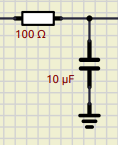

Cálculo analógico

In [25]:
R = 10e3
C = .1e-6
#wc = 1/(R*C)   # wc = 2.pi.fc

fc = 1/(2*np.pi*R*C)

print("R: ",R)
print("C: ",C)
print("fc: ",fc)

R:  10000.0
C:  1e-07
fc:  159.15494309189535


Cálculo en el dominio de laplace

In [4]:
fc = 100
wc = 2*np.pi*fc

num = wc
den = [1, wc]

h_s = signal.TransferFunction(num,den)

Cáculo en discreto Z

In [5]:
h_d = h_s.to_discrete(dt=0.001)
h_d

/usr/local/lib/python3.12/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


TransferFunctionDiscrete(
array([0.46651191]),
array([ 1.        , -0.53348809]),
dt: 0.001
)

## Filtros IIR

### Butter

In [35]:
# N, Wn = signal.buttord(wp, ws, gpass, gstop, analog=False, fs=None)
fs = 1e3
fc = 15
b, a = signal.butter(N=3, Wn=fc, btype="low", fs=1e3)
b, a

(array([9.54425084e-05, 2.86327525e-04, 2.86327525e-04, 9.54425084e-05]),
 array([ 1.        , -2.81157368,  2.64048349, -0.82814628]))

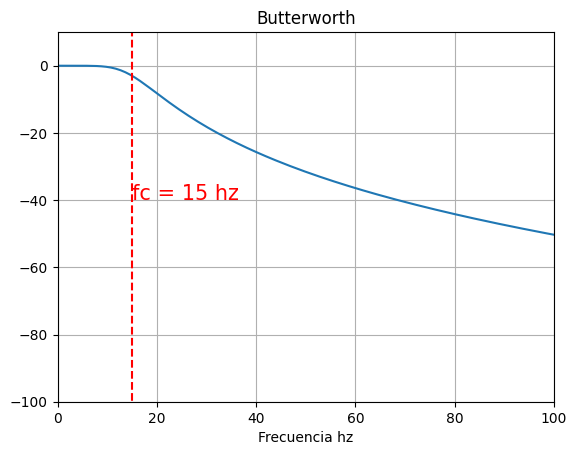

In [36]:
w, h = signal.freqz(b, a, fs=fs)

plt.plot(w, 20*np.log10(abs(h)))
plt.axvline(fc, -10, 10, linestyle="--", color="r")
plt.text(fc,-40,f"fc = {fc} hz", color="r", size=15)
plt.xlabel("Frecuencia hz")
plt.title("Butterworth")
plt.xlim(0,100)
plt.ylim(-100,10)
plt.grid()
plt.show()

### Ellip

In [41]:
fs = 1e3
fc = 15

b, a = signal.ellip(N=3, rp=1, rs=40, Wn=fc, btype='low', analog=False, fs=fs)
b, a

(array([ 0.0031638 , -0.00295323, -0.00295323,  0.0031638 ]),
 array([ 1.        , -2.90118004,  2.81353648, -0.91193529]))

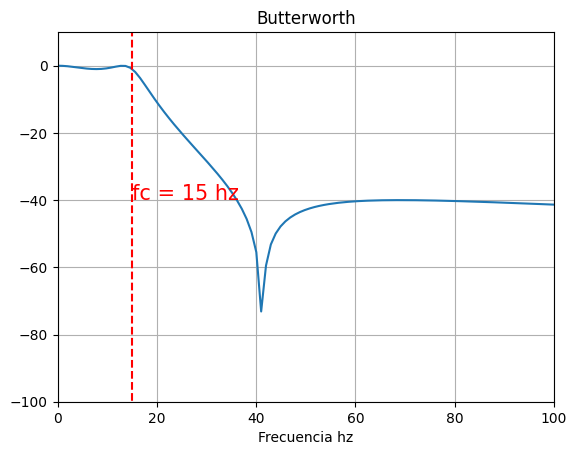

In [42]:
w, h = signal.freqz(b, a, fs=fs)

plt.plot(w, 20*np.log10(abs(h)))
plt.axvline(fc, -10, 10, linestyle="--", color="r")
plt.text(fc,-40,f"fc = {fc} hz", color="r", size=15)
plt.xlabel("Frecuencia hz")
plt.title("Butterworth")
plt.xlim(0,100)
plt.ylim(-100,10)
plt.grid()
plt.show()

## Filtro FIR

In [52]:
signal.get_window

<function scipy.signal.windows._windows.get_window(window, Nx, fftbins=True, *, xp=None, device=None)>

In [92]:
fs = 1e3
fc = 25
numtaps = 71  # debe ser impart

b = signal.firwin(
    numtaps, cutoff=fc,
    fs=fs, window='bartlett',
    pass_zero="lowpass"
    )

b      # signal.lfilter(b, [1], x)

array([-0.00000000e+00, -2.40032272e-04, -5.44738221e-04, -8.99432363e-04,
       -1.28560968e-03, -1.68127849e-03, -2.06140862e-03, -2.39848630e-03,
       -2.66316464e-03, -2.82499520e-03, -2.85322422e-03, -2.71763444e-03,
       -2.38941224e-03, -1.84201831e-03, -1.05203961e-03,  9.26537547e-19,
        1.32889214e-03,  2.94408055e-03,  4.84910130e-03,  7.04114377e-03,
        9.51074740e-03,  1.22416459e-02,  1.52107673e-02,  1.83883950e-02,
        2.17384909e-02,  2.52191774e-02,  2.87833722e-02,  3.23795651e-02,
        3.59527226e-02,  3.94453034e-02,  4.27983633e-02,  4.59527278e-02,
        4.88502057e-02,  5.14348191e-02,  5.36540200e-02,  5.54598678e-02,
        5.36540200e-02,  5.14348191e-02,  4.88502057e-02,  4.59527278e-02,
        4.27983633e-02,  3.94453034e-02,  3.59527226e-02,  3.23795651e-02,
        2.87833722e-02,  2.52191774e-02,  2.17384909e-02,  1.83883950e-02,
        1.52107673e-02,  1.22416459e-02,  9.51074740e-03,  7.04114377e-03,
        4.84910130e-03,  

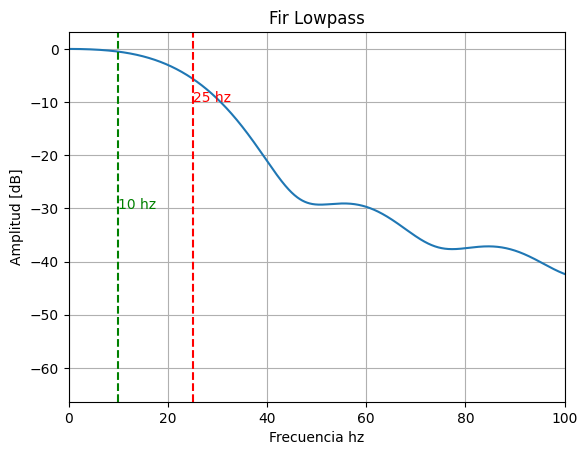

In [93]:
# if you pass fs "w" is in hz, otherwise f = w*fs/(2*np.pi)
w, h = signal.freqz(b, worN=8000, fs=fs)
f1=10

plt.plot(w, 20*np.log10(np.abs(h)))
plt.xlabel('Frecuencia hz')
plt.ylabel('Amplitud [dB]')
plt.title("Fir Lowpass")
plt.grid()
plt.axvline(fc, linestyle="--", color="r")
plt.text(fc, -10, f"{fc} hz", color="r", size=10)

plt.axvline(f1, linestyle="--", color="g")
plt.text(f1, -30, f"{10} hz", color="g", size=10)
plt.xlim(0,100)
plt.show()